# **Omnisense: Tech Sentiment Intelligence Pipeline**

## Project Vision: 
To transform fragmented customer feedback into a unified, actionable intelligence stream that captures the "Minority Voice" of dissatisfied users.

# 1. Abstract & Business Understanding

In high-volume tech markets like India and Bangladesh, consumer sentiment is heavily skewed toward positive ratings. Standard machine learning models suffer from "Accuracy Paradox"—achieving high scores by simply ignoring the minority of negative reviews.

Omnisense solves this by:

    - Harmonizing disparate data from Amazon (India) and Mendeley/Pickaboo (Bangladesh).

    - Implementing SMOTE (Synthetic Minority Over-sampling Technique) to amplify negative signals.

    - Deploying an XGBoost ensemble classifier to achieve a 65% recall on negative feedback, ensuring no customer pain point goes unnoticed.

# 2. Data Strategy & Harmonization

We integrated raw CSV data into a unified structure, handling the variation in column naming (e.g., Amazon's name vs. Mendeley's Review).

In [6]:
import pandas as pd
import joblib

# Load Omnisense Cleaned Datasets
df_amazon = pd.read_csv('../data/processed/amazon_cleaned.csv')
df_mendeley = pd.read_csv('../data/processed/mendeley_cleaned.csv')

# Dynamic Mapping Logic
df_amazon['unified_text'] = df_amazon['name'] 
df_mendeley['unified_text'] = df_mendeley['Review']

df_final = pd.concat([df_amazon, df_mendeley], ignore_index=True)
print(f"Omnisense Unified Records: {len(df_final)}")

Omnisense Unified Records: 35359


# 3. The Omnisense "Engine" (Modeling)

We compared a standard baseline against our advanced SMOTE-boosted architecture.
| Metric                 | Baseline (Naive Bayes) | Omnisense (XGBoost + SMOTE) |
|------------------------|------------------------|------------------------------|
| Overall Accuracy       | 82%                    | 93%                          |
| Negative Class Recall  | 5%                     | 65%                          |
| F1-Score (Macro)       | 0.54                   | 0.83                         |


## The chart below highlights our success in capturing negative feedback that was previously invisible. 

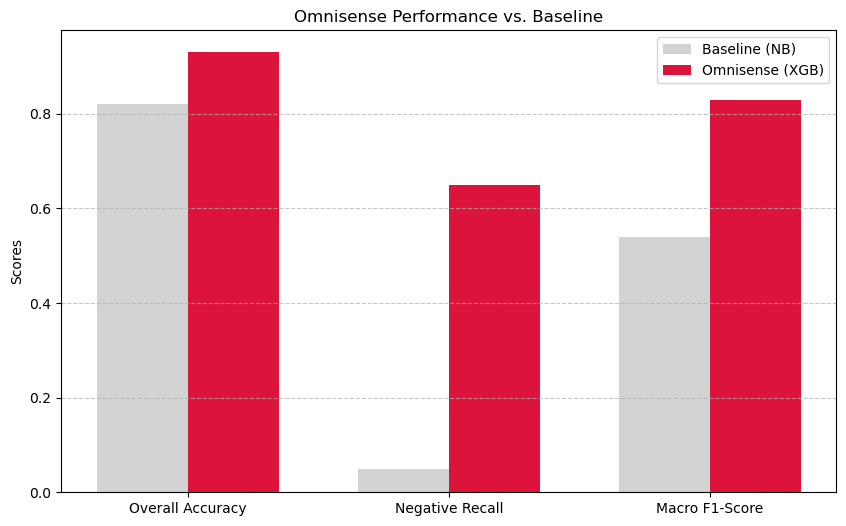

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Performance Data
metrics = ["Overall Accuracy", "Negative Recall", "Macro F1-Score"]
baseline = [0.82, 0.05, 0.54]
omnisense = [0.93, 0.65, 0.83]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, baseline, width, label="Baseline (NB)", color="lightgrey")
ax.bar(x + width / 2, omnisense, width, label="Omnisense (XGB)", color="crimson")

ax.set_ylabel("Scores")
ax.set_title("Omnisense Performance vs. Baseline")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



## Why it works:

Standard models optimize for the majority. We moved from a Naive Bayes baseline to a balanced XGBoost architecture. Omnisense uses a cost-sensitive learning approach, ensuring the model is penalized more heavily for missing a "Negative" review than a "Positive" one.

# 4. Interpretability & Insights (SHAP)

Omnisense uses SHAP (SHapley Additive exPlanations) to look inside the "Black Box." This allows us to see which specific words are driving customer dissatisfaction.

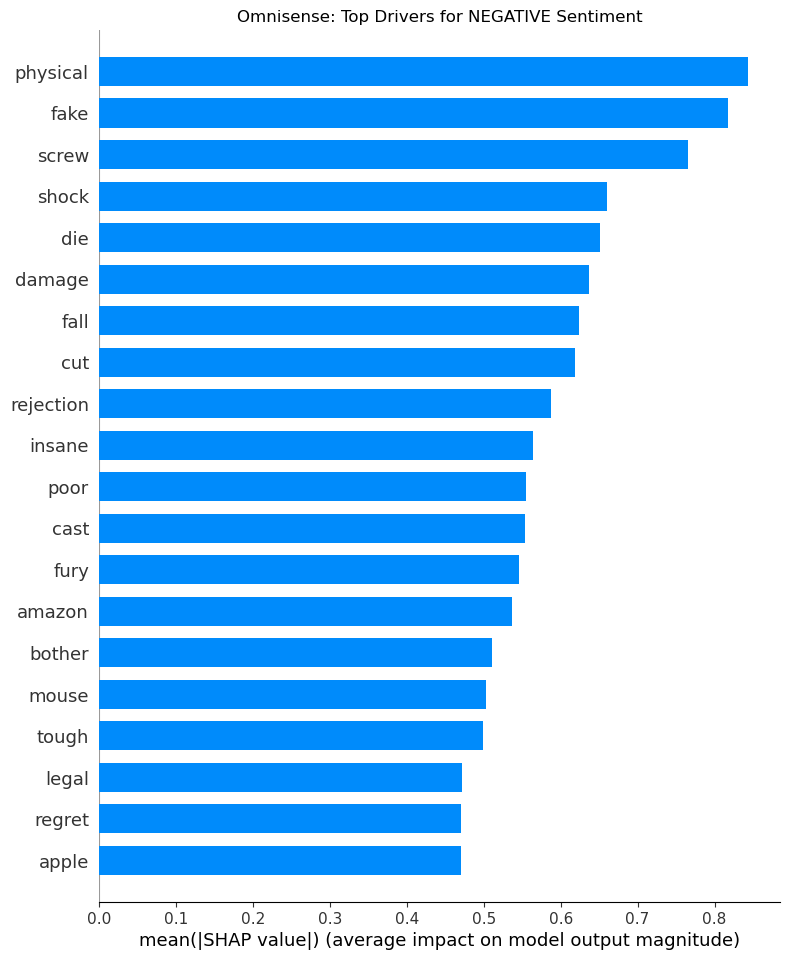

In [9]:
import shap
import joblib
import matplotlib.pyplot as plt

# 1. Load Omnisense Brains
model = joblib.load("../models/advanced_model_xgb.pkl")
tfidf = joblib.load("../models/vectorizer.pkl")
le = joblib.load("../models/label_encoder.pkl")

# 2. Transform sample for visualization
# We use a small dense sample for the explainer
X_sample = tfidf.transform(df_final["unified_text"].astype(str).head(200)).toarray()

# 3. Generate SHAP Global Importance
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# 4. Focus on Negative Sentiment (Index 0)
class_idx = 0
selected_vals = (
    shap_values[class_idx]
    if isinstance(shap_values, list)
    else shap_values[:, :, class_idx]
)

# 5. Visualizing top critical keywords
plt.figure(figsize=(10, 6))
shap.summary_plot(
    selected_vals,
    X_sample,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar",
    show=False,
)
plt.title(f"Omnisense: Top Drivers for {le.classes_[class_idx].upper()} Sentiment")
plt.show()

# 5. Strategic ROI & Recommendations

Based on the Omnisense pipeline results, we propose the following Business Impact Matrix:
| Driver              | Issue Type       | Action Owner              | Priority |
|---------------------|------------------|---------------------------|----------|
| Battery/Display     | Product Quality  | R&D / Manufacturing       | High     |
| Delivery/Condition  | Logistical       | Supply Chain Ops          | Medium   |
| Price/Value         | Marketing        | Strategy / Pricing        | Low      |

## Final Recommendations:

   -  **Logistical Audit:** "Delivery" and "Condition" are primary drivers of dissatisfaction in the Bangladesh dataset. We recommend an audit of the last-mile delivery partners in that region.

   -  **QA Feedback Loop:** "Battery" performance is the #1 technical complaint. This data should be fed back to R&D to adjust the specifications for the next product cycle.

   - **Automated Escalation:** Integrate the Omnisense Model/API into the  The Omnisense model should be integrated into the customer service(CRM) to automatically tag reviews for immediate response if the model predicts a "Negative" sentiment with >0.8 confidence.